# Class-weighted feedforward classifier (Hyperparameter tuning)

Feedforward neural network with batch normalization and dropout, trained as a class-weighted binary classifier.

This notebook is a duplicate of `WeightedClassifier.ipynb`, which can be used for reproducibility and **hyperparameter tuning**.

Saving the model to `.pt` is also found in this notebook.

## Imports

In [1]:
# Matplotlib
import matplotlib.pyplot as plt
# Numpy
import numpy as np
# Torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import copy


In [2]:
# Use GPU if available, else use CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Data

In [3]:
df = pd.read_csv('../data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Hyperprarameter Configuration

In [40]:
# =========================
# CENTRAL CONFIG CELL
# =========================
CONFIG = {
    # Reproducibility
    "seed": 42,

    # Data
    "batch_size": 512, # BEST: 512, tried 256 or 128 for faster training
    "num_workers": 0,  # set to 2 or 4 for faster

    # Model architecture
    "input_dim": 30,
    "hidden_dims": [128, 64, 32],   # try [64, 32] or [256, 128, 64, 32]
    "dropouts": [0.30, 0.20, 0.10], # must match hidden_dims length
    "negative_slope": 0.1,          # LeakyReLU negative slope, try 0.01 or 0.2

    # Training
    "lr": 1e-3, # BEST: 1e-3, tried 5e-4 or 1e-4
    "weight_decay": 1e-4, # BEST: 1e-4, tried 1e-5 or 1e-3
    "num_epochs": 30, # BEST: 30, tried 40
    "patience": 5, #BEST: 5, tried 3 or 7 for early stopping

    # Scheduler
    "scheduler_factor": 0.5,
    "scheduler_patience": 2,

    # Threshold tuning
    "thresholds": np.arange(0.10, 1.00, 0.05),

    # Positive weight for imbalanced loss
    "pos_weight": 10.0, # best, tested values: 10.0, 50.0, 100.0, 150.0
    
    # Saving
    "best_model_path": "best_weighted_fraud_model.pt",
    "last_model_path": "last_weighted_fraud_model.pt"
}

print("Current config:")
for k, v in CONFIG.items():
    print(f"{k}: {v}")

Current config:
seed: 42
batch_size: 512
num_workers: 0
input_dim: 30
hidden_dims: [128, 64, 32]
dropouts: [0.3, 0.2, 0.1]
negative_slope: 0.1
lr: 0.001
weight_decay: 0.0001
num_epochs: 30
patience: 5
scheduler_factor: 0.5
scheduler_patience: 2
thresholds: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85 0.9  0.95]
pos_weight: 10.0
best_model_path: best_weighted_fraud_model.pt
last_model_path: last_weighted_fraud_model.pt


## Data Preprocessing

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = CONFIG["seed"]
np.random.seed(SEED)
torch.manual_seed(SEED)

# Separate features and target
X = df.drop('Class', axis=1).copy()
y = df['Class'].astype(np.float32).values

# Train-test split (80-20)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Further split training data into train and validation sets (75-25 of the 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=SEED, stratify=y_train_full
)

# Feature engineering for skewed columns
for frame in (X_train, X_val, X_test):
    frame['Amount'] = np.log1p(frame['Amount'])
    frame['Time'] = np.log1p(frame['Time'])

# Normalize using train statistics only to prevent data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Calculate class weights to handle imbalance
"""This is where we calculate the weights to handle the class imbalance in our dataset. 
The positive class (fraudulent transactions) is much rarer than the negative class (normal transactions), 
so we assign a higher weight to the positive class to ensure that the model pays more attention to it during training."""
n_train = len(y_train)
n_fraud = int((y_train == 1).sum().item())
n_normal = int((y_train == 0).sum().item())
POS_WEIGHT = CONFIG["pos_weight"] # best, tested values: 50.0, 100.0, 150.0
pos_weight = torch.tensor([POS_WEIGHT], dtype=torch.float32).to(device)

print(f"Train samples: {n_train}")
print(f"Normal transactions: {n_normal}")
print(f"Fraudulent transactions: {n_fraud}")
print(f"Positive class weight: {pos_weight.item():.4f}")


Train samples: 170883
Normal transactions: 170588
Fraudulent transactions: 295
Positive class weight: 10.0000


## Create DataLoader

In [42]:
# Custom Dataset class
class FraudDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Create datasets
train_dataset = FraudDataset(X_train, y_train)
val_dataset = FraudDataset(X_val, y_val)
test_dataset = FraudDataset(X_test, y_test)

# DataLoader configuration
BATCH_SIZE = CONFIG["batch_size"] # default 512, try 256 or 128 for faster training
NUM_WORKERS = CONFIG["num_workers"] # set to 2 or 4 for faster

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f"Train DataLoader: {len(train_dataloader)} batches")
print(f"Val DataLoader: {len(val_dataloader)} batches")
print(f"Test DataLoader: {len(test_dataloader)} batches")


Train DataLoader: 334 batches
Val DataLoader: 112 batches
Test DataLoader: 112 batches


In [43]:
# Test DataLoader by iterating through a few batches
print("Sample batches from training data:\n")

for batch_number, (inputs, outputs) in enumerate(train_dataloader):
    print("---")
    print(f"Batch number: {batch_number}")
    print(f"Inputs shape: {inputs.shape}")
    print(f"Outputs shape: {outputs.shape}")
    
    if batch_number == 2:  # Show first 3 batches
        break


Sample batches from training data:

---
Batch number: 0
Inputs shape: torch.Size([512, 30])
Outputs shape: torch.Size([512])
---
Batch number: 1
Inputs shape: torch.Size([512, 30])
Outputs shape: torch.Size([512])
---
Batch number: 2
Inputs shape: torch.Size([512, 30])
Outputs shape: torch.Size([512])


# Model

In [44]:
class FraudDetectionNet(nn.Module):
    def __init__(self, input_features=30, hidden_dims=None, dropouts=None, negative_slope=0.1):
        super(FraudDetectionNet, self).__init__()

        if hidden_dims is None:
            hidden_dims = [128, 64, 32]
        if dropouts is None:
            dropouts = [0.30, 0.20, 0.10]

        assert len(hidden_dims) == len(dropouts), "hidden_dims and dropouts must have the same length"

        layers = []
        in_dim = input_features

        for i, (hidden_dim, dropout_rate) in enumerate(zip(hidden_dims, dropouts)):
            layers.append(nn.Linear(in_dim, hidden_dim))

            # BatchNorm for all hidden layers except you can also choose to use all
            if i < 2:  
                layers.append(nn.BatchNorm1d(hidden_dim))

            layers.append(nn.LeakyReLU(negative_slope))
            layers.append(nn.Dropout(dropout_rate))

            in_dim = hidden_dim

        layers.append(nn.Linear(in_dim, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Build model from config
model = FraudDetectionNet(
    input_features=CONFIG["input_dim"],
    hidden_dims=CONFIG["hidden_dims"],
    dropouts=CONFIG["dropouts"],
    negative_slope=CONFIG["negative_slope"]
).to(device)

print(model)

FraudDetectionNet(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.1)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): LeakyReLU(negative_slope=0.1)
    (10): Dropout(p=0.1, inplace=False)
    (11): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Training Setup

In [45]:
# Compute positive class weight from training labels only
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=CONFIG["scheduler_factor"],
    patience=CONFIG["scheduler_patience"]
)

print("Loss Function: BCEWithLogitsLoss with class weighting")
print(f"Learning rate: {CONFIG['lr']}")
print(f"Weight decay: {CONFIG['weight_decay']}")
print(f"Positive weight (fraud): {pos_weight.item():.4f}")

Loss Function: BCEWithLogitsLoss with class weighting
Learning rate: 0.001
Weight decay: 0.0001
Positive weight (fraud): 578.2644


# Training Loop

Added:
- proper probability conversion with sigmoid
- early stopping
- learning-rate scheduling

In [46]:
from sklearn.metrics import average_precision_score

def collect_probs_and_labels(model, dataloader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            logits = model(inputs).squeeze(1)
            probs = torch.sigmoid(logits).cpu().numpy()

            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

    return np.array(all_probs), np.array(all_labels)

def trainer(model, train_loader, val_loader, criterion, optimizer, scheduler, device, config):
    best_state = None
    best_val_pr_auc = -1.0
    patience_counter = 0

    train_losses = []
    val_losses = []
    val_pr_aucs = []

    for epoch in range(config["num_epochs"]):
        # ===== TRAIN =====
        model.train()
        running_train_loss = 0.0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ===== VALIDATION LOSS =====
        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device).unsqueeze(1)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()

        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # ===== VALIDATION PR-AUC =====
        val_probs, val_labels = collect_probs_and_labels(model, val_loader, device)
        val_pr_auc = average_precision_score(val_labels, val_probs)
        val_pr_aucs.append(val_pr_auc)

        scheduler.step(val_pr_auc)

        print(
            f"Epoch [{epoch+1}/{config['num_epochs']}] | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val PR-AUC: {val_pr_auc:.4f}"
        )

        # Save best model
        if val_pr_auc > best_val_pr_auc:
            best_val_pr_auc = val_pr_auc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, config["best_model_path"])
            patience_counter = 0
            print(f"  -> Best model saved to {config['best_model_path']}")
        else:
            patience_counter += 1

        if patience_counter >= config["patience"]:
            print("Early stopping triggered.")
            break

    # Load best model back
    if best_state is not None:
        model.load_state_dict(best_state)

    # Save final loaded-best model again
    torch.save(model.state_dict(), config["last_model_path"])
    print(f"Final model saved to {config['last_model_path']}")

    return train_losses, val_losses, val_pr_aucs

In [47]:
print("Starting training...\n")

train_losses, val_losses, val_pr_aucs = trainer(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    config=CONFIG
)

print("\nTraining complete!")

Starting training...

Epoch [1/30] | Train Loss: 0.4651 | Val Loss: 0.5540 | Val PR-AUC: 0.6937
  -> Best model saved to best_weighted_fraud_model.pt
Epoch [2/30] | Train Loss: 0.3381 | Val Loss: 0.4752 | Val PR-AUC: 0.6560
Epoch [3/30] | Train Loss: 0.2627 | Val Loss: 0.5644 | Val PR-AUC: 0.6674
Epoch [4/30] | Train Loss: 0.2132 | Val Loss: 0.6231 | Val PR-AUC: 0.6808
Epoch [5/30] | Train Loss: 0.1893 | Val Loss: 0.6619 | Val PR-AUC: 0.6799
Epoch [6/30] | Train Loss: 0.1849 | Val Loss: 0.7266 | Val PR-AUC: 0.6967
  -> Best model saved to best_weighted_fraud_model.pt
Epoch [7/30] | Train Loss: 0.1621 | Val Loss: 0.8130 | Val PR-AUC: 0.6886
Epoch [8/30] | Train Loss: 0.1337 | Val Loss: 0.8797 | Val PR-AUC: 0.6970
  -> Best model saved to best_weighted_fraud_model.pt
Epoch [9/30] | Train Loss: 0.1466 | Val Loss: 0.8832 | Val PR-AUC: 0.7020
  -> Best model saved to best_weighted_fraud_model.pt
Epoch [10/30] | Train Loss: 0.1223 | Val Loss: 0.9595 | Val PR-AUC: 0.6929
Epoch [11/30] | Train

# Evaluation & Testing

For this dataset, raw accuracy alone is not enough because fraud cases are extremely rare.  
So we report:
- **Accuracy**: Overall proportion of correctly classified transactions.
- **Balanced Accuracy**: Average performance across both normal and fraud classes.
- **Precision**: Of predicted frauds, how many are actually frauds?
- **Recall**: Of actual frauds, how many did we catch?
- **F1 Score**: Balance between precision and recall.
- **ROC-AUC**: Area under the ROC curve - measures discriminative ability.
- **PR-AUC**: Precision-recall performance across thresholds, especially useful for imbalanced data.


In [48]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

def evaluate_at_threshold(y_true, y_probs, threshold):
    y_pred = (y_probs >= threshold).astype(int)

    metrics = {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_probs),
        "pr_auc": average_precision_score(y_true, y_probs),
        "confusion_matrix": confusion_matrix(y_true, y_pred)
    }
    return metrics

# Validation probabilities for threshold selection
val_probs, val_labels = collect_probs_and_labels(model, val_dataloader, device)

threshold_results = []
for threshold in CONFIG["thresholds"]:
    metrics = evaluate_at_threshold(val_labels, val_probs, threshold)
    threshold_results.append(metrics)

results_df = pd.DataFrame([
    {
        "threshold": m["threshold"],
        "accuracy": m["accuracy"],
        "balanced_accuracy": m["balanced_accuracy"],
        "precision": m["precision"],
        "recall": m["recall"],
        "f1": m["f1"],
        "roc_auc": m["roc_auc"],
        "pr_auc": m["pr_auc"]
    }
    for m in threshold_results
])

display(results_df.sort_values(by="f1", ascending=False).head(10))

best_threshold = results_df.sort_values(by="f1", ascending=False).iloc[0]["threshold"]
print(f"Best threshold based on validation F1: {best_threshold:.2f}")

,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
17,0.95,0.997770,0.913174,0.427083,0.828283,0.563574,0.956357,0.70373
16,0.90,0.995523,0.917090,0.257764,0.838384,0.394299,0.956357,0.70373
15,0.85,0.993188,0.920963,0.183807,0.848485,0.302158,0.956357,0.70373
14,0.80,0.989028,0.918879,0.121037,0.848485,0.211854,0.956357,0.70373
13,0.75,0.983954,0.916337,0.085453,0.848485,0.155268,0.956357,0.70373
12,0.70,0.980548,0.924715,0.072820,0.868687,0.134375,0.956357,0.70373
11,0.65,0.977564,0.923220,0.063657,0.868687,0.118621,0.956357,0.70373
10,0.60,0.974615,0.921743,0.056616,0.868687,0.106304,0.956357,0.70373
9,0.55,0.971876,0.925413,0.051878,0.878788,0.097973,0.956357,0.70373
8,0.50,0.969436,0.924191,0.047907,0.878788,0.090862,0.956357,0.70373


Best threshold based on validation F1: 0.95


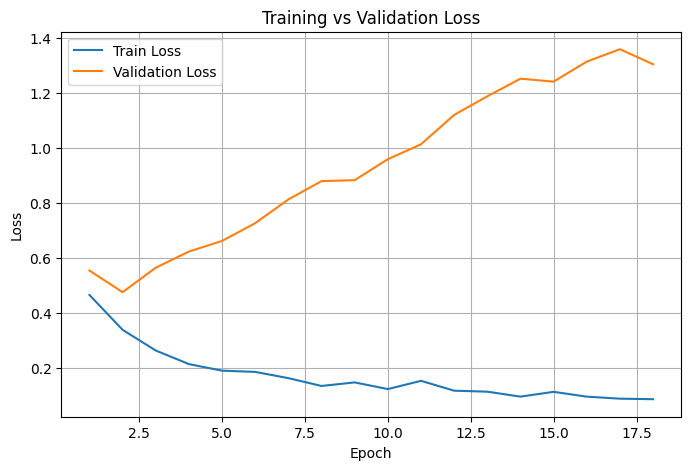

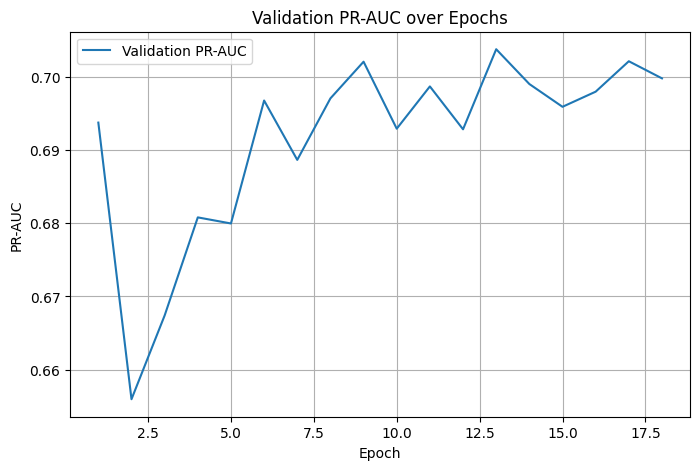

In [49]:
import matplotlib.pyplot as plt

def plot_training_curves(train_losses, val_losses, val_pr_aucs):
    epochs = range(1, len(train_losses) + 1)

    # ----- Loss Plot -----
    plt.figure(figsize=(8,5))
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid()
    plt.show()

    # ----- PR-AUC Plot (better than accuracy for imbalance) -----
    plt.figure(figsize=(8,5))
    plt.plot(epochs, val_pr_aucs, label="Validation PR-AUC")
    plt.xlabel("Epoch")
    plt.ylabel("PR-AUC")
    plt.title("Validation PR-AUC over Epochs")
    plt.legend()
    plt.grid()
    plt.show()

# Call it
plot_training_curves(train_losses, val_losses, val_pr_aucs)

Best hyperparameters found:

| Category      | Parameter       | Value / Setting         | Notes                                    |
| ------------- | --------------- | ----------------------- | ---------------------------------------- |
| **General**   | Seed            | 42                      | For reproducibility                      |
| **Data**      | Batch Size      | 512                     | Best; also tested 256, 128               |
|               | Num Workers     | 0                       | Can use 2–4 for faster loading           |
| **Model**     | Input Dimension | 30                      | Time, Amount, V1–V28                     |
|               | Hidden Layers   | [128, 64, 32]           | Also tested [64, 32], [256, 128, 64, 32] |
|               | Dropout Rates   | [0.30, 0.20, 0.10]      | Must match hidden layers                 |
|               | Activation      | LeakyReLU (slope = 0.1) | Tested 0.01, 0.2                         |
| **Training**  | Learning Rate   | 1e-3                    | Best; also tested 5e-4, 1e-4             |
|               | Weight Decay    | 1e-4                    | Best; also tested 1e-5, 1e-3             |
|               | Epochs          | 30                      | Also tested 40                           |
|               | Patience        | 5                       | Early stopping (tested 3, 7)             |
| **Scheduler** | Factor          | 0.5                     | LR reduction factor                      |
|               | Patience        | 2                       | Scheduler patience                       |
